# RF-3DGS 数据集生成 (Etoile 场景, 多辐射源)

基于 RF-3DGS 教程的数据格式，使用 Sionna 内置 etoile 场景生成 MPC（多径分量）空间频谱数据集。

**输出格式 (COLMAP 兼容):**
```
dataset/
├── images/          — 频谱图像 (PNG, jet colormap)
├── sparse/
│   └── 0/
│       ├── cameras.txt   — 相机内参 (PINHOLE 模型)
│       ├── images.txt    — 相机外参 (四元数旋转 + 平移)
│       └── points3D.txt  — 初始点云
├── train_index.txt  — 训练集索引
└── test_index.txt   — 测试集索引
```

**特性:**
- 多个全向天线辐射源 (TX)
- 通过 coverage map 确保接收点不在墙内
- MPC/Ideal Spectrum 方式 (无需波束赋形)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import cv2
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
tf.get_logger().setLevel('ERROR')

import sionna
import sionna.rt
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver, Camera
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import imageio

import time
seed = int(time.time())
np.random.seed(seed)
tf.random.set_seed(seed)

print(f"本次的随机种子：{seed}")

本次的随机种子：1773418521


## 1. 参数配置

In [2]:
# ========== 输出目录 ==========
OUTPUT_DIR = './dataset/etoile_demo'

# ========== 场景参数 ==========
SCENE_FREQ = 3.5e9          # 3.5 GHz (5G 中频段)
RX_HEIGHT = 1.5              # 接收器高度 (m)
TX_HEIGHT = 25.0             # 发射器高度 (m)

# ========== 图像参数 (与 RF-3DGS 教程一致) ==========
IMAGE_WIDTH = 300
IMAGE_HEIGHT = 200
FOV = 90                     # 水平视场角 (度)

# ========== 采样参数 ==========
NUM_RX_SAMPLES = 810         # 最终接收点数量
VIEW_ANGLES = [-np.pi/2, 0, np.pi/2, np.pi]  # 每个位置4个朝向
RENDER_NUM_SAMPLES=256 # 视觉渲染中每像素采样数越多，图像越平

# ========== 射线追踪参数 ==========
MAX_DEPTH = 5                # 最大反射/散射深度
NUM_RT_SAMPLES = int(1e6)    # 射线数量

# ========== 频谱渲染参数 (高斯核) ==========
IMAGE_SCALE = 3              # 等距圆柱投影分辨率倍数
KERNEL_SIZE = 3              # 高斯核大小乘数
KERNEL_SIGMA = 3             # 高斯核标准差 (像素)

# ========== Train/Test 分割 ==========
TRAIN_RATIO = 0.8            # 训练集比例

## 2. 加载场景 & 配置天线

In [3]:
scene = load_scene(sionna.rt.scene.etoile)
scene.frequency = SCENE_FREQ

# TX: 单个全向天线 (每个辐射源)
scene.tx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V",
)

# RX: 全向天线 (MPC spectrum)
scene.rx_array = PlanarArray(
    num_rows=8,
    num_cols=8,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="V",
)

## 3. 添加多个辐射源 (TX)

在场景中不同位置放置全向天线辐射源，模拟多基站场景。
TX 放置在建筑物高度，确保具有良好的覆盖。

In [4]:
# 清除已有设备
for name in list(scene.transmitters.keys()):
    scene.remove(name)
for name in list(scene.receivers.keys()):
    scene.remove(name)

# 定义多个辐射源位置 (x, y, z)
# etoile 场景以凯旋门为中心，多条大道向外辐射
# TX 放在不同方位的高处
tx_positions = [
    [60,   40,  TX_HEIGHT],    # 东北区域
    [-50, -70,  TX_HEIGHT],    # 西南区域
    [80,  -30,  TX_HEIGHT],    # 东南区域
    [-125,32,TX_HEIGHT * 2],
    [-43,156,TX_HEIGHT],
    [-212,-75,TX_HEIGHT],
]

for i, pos in enumerate(tx_positions):
    # 军营中师旅级固定台站功率125W
    tx = Transmitter(name=f"tx_{i}", position=pos,power_dbm=51)
    scene.add(tx)
    print(f"  TX_{i}: position = {pos}")

num_tx = len(tx_positions)
print(f"\n共添加 {num_tx} 个辐射源")

  TX_0: position = [60, 40, 25.0]
  TX_1: position = [-50, -70, 25.0]
  TX_2: position = [80, -30, 25.0]
  TX_3: position = [-125, 32, 50.0]
  TX_4: position = [-43, 156, 25.0]
  TX_5: position = [-212, -75, 25.0]

共添加 6 个辐射源


# 4. 添加RX并用LoS验证位置有效性

In [5]:
print("正在通过 LoS/反射 验证生成有效接收位置...")

# 在场景范围内生成候选网格
# etoile 场景大约 ±200m, 街道集中在 ±120m 范围内
GRID_SPACING = 10  # 每 10m 一个候选点
grid_x = np.arange(-200, 155, GRID_SPACING)
grid_y = np.arange(-200, 155, GRID_SPACING)

candidates = []
for x in grid_x:
    for y in grid_y:
        # 添加小随机偏移避免所有点落在同一网格线上
        x_offset = np.random.uniform(-GRID_SPACING * 0.3, GRID_SPACING * 0.3)
        y_offset = np.random.uniform(-GRID_SPACING * 0.3, GRID_SPACING * 0.3)
        candidates.append([float(x + x_offset), float(y + y_offset), RX_HEIGHT])

print(f"候选点: {len(candidates)} 个")

# PathSolver 只创建一次 (避免循环内重复创建)
p_solver = PathSolver()

# 验证: 对每个候选位置计算路径, 有信号说明在室外
valid_rx_locs = []
for i, pos in enumerate(candidates):
    if i % 50 == 0:
        print(f"  验证进度: {i}/{len(candidates)}")
    try:
        scene.remove("rx_validate")
    except Exception:
        pass

    rx = Receiver(name="rx_validate", position=pos)
    scene.add(rx)

    try:
        paths = p_solver(
            scene=scene,
            max_depth=1,
            refraction=True,
            diffraction=False,
            diffuse_reflection=False,
            samples_per_src=int(1e5)
        )
        # 检查是否有任何有效路径
        total_gain = float(np.sum(np.abs(paths.a)))
        if total_gain > 0:
            valid_rx_locs.append(pos)
    except Exception:
        pass  # 跳过计算失败的位置

scene.remove("rx_validate")

print(f"\nLoS 验证通过: {len(valid_rx_locs)} / {len(candidates)} 个有效位置")

# 从有效位置中随机采样
if len(valid_rx_locs) > NUM_RX_SAMPLES:
    indices = np.random.choice(len(valid_rx_locs), NUM_RX_SAMPLES, replace=False)
    rx_locs = [valid_rx_locs[i] for i in indices]
else:
    rx_locs = valid_rx_locs

print(f"最终采样: {len(rx_locs)} 个接收点")

for i, pos in enumerate(rx_locs):
    rx = Receiver(name=f"rx_final_{i}", position=pos)
    scene.add(rx)

正在通过 LoS/反射 验证生成有效接收位置...
候选点: 1296 个
  验证进度: 0/1296
  验证进度: 50/1296
  验证进度: 100/1296
  验证进度: 150/1296
  验证进度: 200/1296
  验证进度: 250/1296
  验证进度: 300/1296
  验证进度: 350/1296
  验证进度: 400/1296
  验证进度: 450/1296
  验证进度: 500/1296
  验证进度: 550/1296
  验证进度: 600/1296
  验证进度: 650/1296
  验证进度: 700/1296
  验证进度: 750/1296
  验证进度: 800/1296
  验证进度: 850/1296
  验证进度: 900/1296
  验证进度: 950/1296
  验证进度: 1000/1296
  验证进度: 1050/1296
  验证进度: 1100/1296
  验证进度: 1150/1296
  验证进度: 1200/1296
  验证进度: 1250/1296

LoS 验证通过: 1008 / 1296 个有效位置
最终采样: 810 个接收点


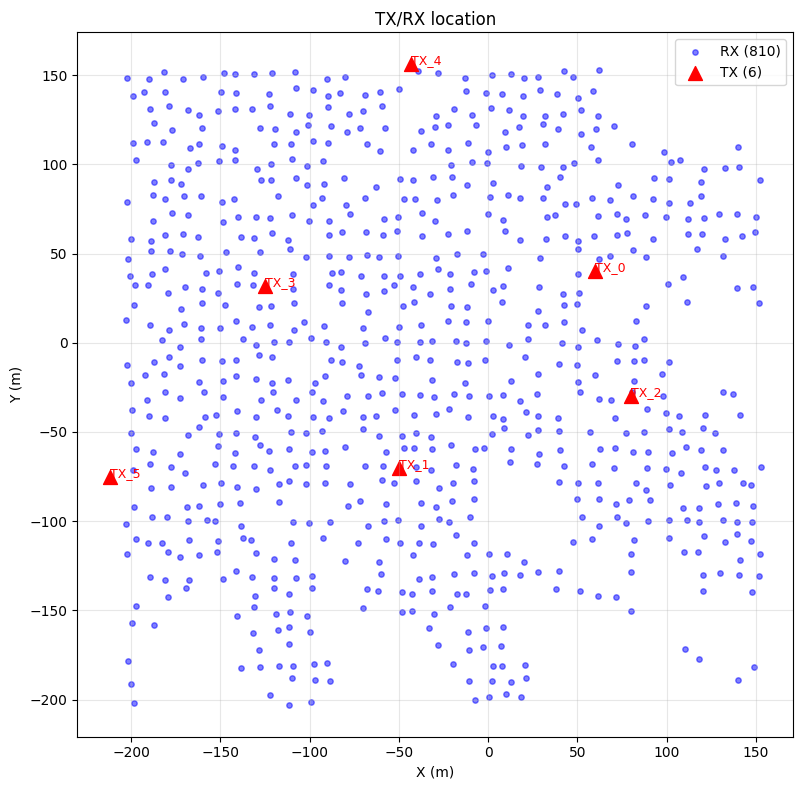

数据集大小: 810 个位置 × 4 个朝向 = 3240 张频谱图


In [6]:
# 可视化 TX 和 RX 位置
rx_locs_arr = np.array(rx_locs)
tx_locs_arr = np.array(tx_positions)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

ax.scatter(rx_locs_arr[:, 0], rx_locs_arr[:, 1],
           c='blue', marker='o', s=15, alpha=0.5, label=f'RX ({len(rx_locs)})')
ax.scatter(tx_locs_arr[:, 0], tx_locs_arr[:, 1],
           c='red', marker='^', s=100, label=f'TX ({num_tx})')

for i, pos in enumerate(tx_positions):
    ax.annotate(f'TX_{i}', (pos[0], pos[1]), fontsize=9, color='red')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('TX/RX location')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"数据集大小: {len(rx_locs)} 个位置 × {len(VIEW_ANGLES)} 个朝向 = {len(rx_locs)*len(VIEW_ANGLES)} 张频谱图")


In [7]:
# Monkey-patch: Sionna 传小写 'xyz' 但新版 pythreejs 要求大写 'XYZ'
import pythreejs
_orig_euler_init = pythreejs.Euler.__init__
def _patched_euler_init(self, *args, **kwargs):
    if args and isinstance(args[0], str):
        args = (args[0].upper(), *args[1:])
    if 'order' in kwargs and isinstance(kwargs['order'], str):
        kwargs['order'] = kwargs['order'].upper()
    _orig_euler_init(self, *args, **kwargs)
pythreejs.Euler.__init__ = _patched_euler_init

scene.preview()

## 5. 工具函数

包含 COLMAP 格式 I/O、频谱渲染、坐标变换等工具。

In [8]:
# ==================== COLMAP 格式相关 ====================

class ColmapCamera:
    """COLMAP 相机内参"""
    def __init__(self, id, model, width, height, params):
        self.id = id
        self.model = model
        self.width = width
        self.height = height
        self.params = params   # [fx, fy, cx, cy]

class colmap_Image:
    """COLMAP 图像位姿 (camera-to-world)"""
    def __init__(self, id, qvec, tvec, camera_id, name, xys=None, point3D_ids=None):
        self.id = id
        self.qvec = qvec      # [qw, qx, qy, qz] camera-to-world rotation
        self.tvec = tvec       # camera-to-world translation
        self.camera_id = camera_id
        self.name = name
        self.xys = xys if xys is not None else np.array([])
        self.point3D_ids = point3D_ids if point3D_ids is not None else []

def save_intrinsics_text(path, cameras):
    """保存 cameras.txt (无注释头)"""
    with open(path, "w") as fid:
        for cam_id, cam in cameras.items():
            params_str = " ".join(map(str, cam.params))
            fid.write(f"{cam_id} {cam.model} {cam.width} {cam.height} {params_str}\n")

def save_extrinsics_text(path, images):
    """保存 images.txt (c2w 四元数 + c2w 平移)"""
    with open(path, "w") as fid:
        for img_id, img in images.items():
            qvec_str = " ".join(map(str, img.qvec))
            tvec_str = " ".join(map(str, img.tvec))
            fid.write(f"{img_id} {qvec_str} {tvec_str} {img.camera_id} {img.name}\n")
            fid.write("\n")

def save_points3D_txt(path, num_points=100000, bounds_min=(-150, -150, 0), bounds_max=(150, 150, 50)):
    """
    生成随机初始点云 (Fake Point Cloud), 供 3DGS 初始化高斯球使用。
    etoile 场景范围: XY ±120m, Z 0~40m。
    """
    print(f"正在生成 {num_points} 个随机初始 3D 高斯点供训练使用...")
    with open(path, "w") as f:
        f.write("# 3D point list with one line of data per point:\n")
        f.write("# POINT3D_ID, X, Y, Z, R, G, B, ERROR, TRACK[] as (IMAGE_ID, POINT2D_IDX)\n")
        pts_x = np.random.uniform(bounds_min[0], bounds_max[0], num_points)
        pts_y = np.random.uniform(bounds_min[1], bounds_max[1], num_points)
        pts_z = np.random.uniform(bounds_min[2], bounds_max[2], num_points)
        colors = np.random.randint(0, 255, (num_points, 3))
        for i in range(num_points):
            x, y, z = pts_x[i], pts_y[i], pts_z[i]
            r, g, b = colors[i]
            f.write(f"{i+1} {x:.4f} {y:.4f} {z:.4f} {r} {g} {b} 0.0\n")

def calculate_camera_intrinsics(width, height, focal_length):
    """计算 PINHOLE 相机内参"""
    fx = fy = focal_length
    cx = width / 2.0
    cy = height / 2.0
    return fx, fy, cx, cy

# ==================== 坐标变换 (c2w) ====================

def euler_to_quaternion(euler):
    """
    将 Sionna 欧拉角 (yaw, pitch, roll) 转换为 COLMAP 格式的
    camera-to-world (c2w) 旋转矩阵和四元数。

    1. R_posz2posx: COLMAP 初始相机方向 (+z) 旋转到 Sionna 阵列初始方向 (+x)
    2. R_posx2array: Sionna 阵列从初始方向旋转到采样方向
    3. R_w2c = R_posx2array * R_posz2posx
    4. R_c2w = R_w2c.inv()
    5. 四元数转为 COLMAP scalar-first 格式 [qw, qx, qy, qz]
    """
    # COLMAP 默认相机朝 +z, 旋转到 Sionna 阵列初始朝 +x
    R_posz2posx = Rotation.from_euler('ZYX', [-np.pi/2, 0.0, -np.pi/2])

    # Sionna 阵列从初始方向旋转到采样方向
    yaw, pitch, roll = euler
    R_posx2array = Rotation.from_euler('ZYX', [yaw, pitch, roll])

    # world-to-camera (内旋: 右乘顺序, 先 R_posz2posx 再 R_posx2array)
    R_w2c = R_posx2array * R_posz2posx

    # camera-to-world
    R_c2w = R_w2c.inv()

    # 转换为四元数 (COLMAP scalar-first: qw, qx, qy, qz)
    q = R_c2w.as_quat()  # scipy 返回 [qx, qy, qz, qw]
    qvec_c2w = [q[3], q[0], q[1], q[2]]

    return R_c2w, qvec_c2w

# ==================== 频谱渲染 (高斯核) ====================

def plot_multi_tx_spectrum(paths, num_tx, image_scale=3, kernel_size=3, kernel_sigma=3):
    """
    渲染多 TX 合并的 MPC 空间频谱 (等距圆柱投影)。

    使用高斯核:
    - 每个 MPC 在其 AoA 位置放置高斯核, 强度正比于振幅
    - 高斯核大小由 kernel_size * kernel_sigma 决定
    - 最终转为 dB 域, 零值区域设为最小值 - 10 dB

    Sionna v1.0 PathSolver API:
      - paths.a -> tuple (a_real, a_imag), 各 shape [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
      - paths.theta_r -> shape [num_rx, num_tx, num_paths]
      - paths.phi_r   -> shape [num_rx, num_tx, num_paths]

    返回: [360*scale, 180*scale] 的 dB 域频谱
    """
    # 解包 paths.a (Sionna v1: tuple (a_real, a_imag))
    a_real, a_imag = paths.a
    a_real_np = np.array(a_real)
    a_imag_np = np.array(a_imag)

    # 角度: shape [num_rx, num_tx, num_paths]
    theta_r_np = np.array(paths.theta_r)
    phi_r_np = np.array(paths.phi_r)

    img_h = 360 * image_scale
    img_w = 180 * image_scale
    img = np.zeros((img_h, img_w))

    # 高斯核参数
    sigma_x, sigma_y = kernel_sigma, kernel_sigma
    size_x = int(kernel_size * sigma_x) | 1  # 确保奇数
    size_y = int(kernel_size * sigma_y) | 1
    x = np.linspace(-size_x // 2, size_x // 2, size_x)
    y = np.linspace(-size_y // 2, size_y // 2, size_y)
    x, y = np.meshgrid(x, y)
    gauss_kernel = np.exp(-(x**2 / (2 * sigma_x**2) + y**2 / (2 * sigma_y**2)))

    for tx_idx in range(num_tx):
        # theta_r / phi_r: [num_rx, num_tx, num_paths], 取 rx_idx=0
        theta = theta_r_np[0, tx_idx, :] * 180 / np.pi
        phi = phi_r_np[0, tx_idx, :] * 180 / np.pi
        # a: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths], 取 rx=0, rx_ant=0, tx_ant=0
        amps = np.sqrt(a_real_np[0, 0, tx_idx, 0, :]**2 + a_imag_np[0, 0, tx_idx, 0, :]**2)

        for idx, intensity in enumerate(amps):
            if intensity > 0:
                # 高斯核加权: intensity / sum(kernel)
                path_dot = gauss_kernel * intensity / np.sum(gauss_kernel)

                phi_idx = int(-phi[idx] + 180) * image_scale
                theta_idx = int(theta[idx]) * image_scale

                xmin = max(0, phi_idx - size_x // 2)
                xmax = min(img_h, phi_idx + size_x // 2 + 1)
                ymin = max(0, theta_idx - size_y // 2)
                ymax = min(img_w, theta_idx + size_y // 2 + 1)

                gauss_xmin = max(0, size_x // 2 - phi_idx)
                gauss_xmax = min(size_x, img_h - phi_idx + size_x // 2)
                gauss_ymin = max(0, size_y // 2 - theta_idx)
                gauss_ymax = min(size_y, img_w - theta_idx + size_y // 2)

                img[xmin:xmax, ymin:ymax] += path_dot[gauss_xmin:gauss_xmax, gauss_ymin:gauss_ymax]

    # 转 dB 域
    non_zero_mask = img != 0.0
    zero_mask = img == 0.0
    if np.any(non_zero_mask):
        img[non_zero_mask] = 10 * np.log10(img[non_zero_mask])
        img[zero_mask] = np.min(img[non_zero_mask]) - 10
    else:
        img[:] = -100

    return img

def jet_colormap_convert(array_2d):
    """将 2D 数组归一化并应用 jet colormap -> [H, W, 3] RGB float (0~1)"""
    arr_min, arr_max = np.min(array_2d), np.max(array_2d)
    if arr_max - arr_min < 1e-12:
        normalized = np.zeros_like(array_2d)
    else:
        normalized = (array_2d - arr_min) / (arr_max - arr_min)
    jet = plt.get_cmap('jet')
    colored = jet(normalized)[:, :, :3]
    return colored

# ==================== 等距圆柱 → 透视投影 (与 RF-3DGS 教程一致) ====================

def xyz2lonlat(xyz):
    norm = np.linalg.norm(xyz, axis=-1, keepdims=True)
    xyz_norm = xyz / norm
    lon = np.arctan2(xyz_norm[..., 0:1], xyz_norm[..., 2:])
    lat = np.arcsin(xyz_norm[..., 1:2])
    return np.concatenate([lon, lat], axis=-1)

def lonlat2XY(lonlat, shape):
    X = (lonlat[..., 0:1] / (2 * np.pi) + 0.5) * (shape[1] - 1)
    Y = (lonlat[..., 1:] / (np.pi) + 0.5) * (shape[0] - 1)
    return np.concatenate([X, Y], axis=-1)

class Equirectangular:
    """等距圆柱投影类"""
    def __init__(self, img):
        self._img = img
        [self._height, self._width, _] = self._img.shape

    def GetPerspective(self, FOV, THETA, PHI, height, width):
        f = 0.5 * width * 1 / np.tan(0.5 * FOV / 180.0 * np.pi)
        cx = (width - 1) / 2.0
        cy = (height - 1) / 2.0
        K = np.array([
            [f, 0, cx],
            [0, f, cy],
            [0, 0,  1],
        ], np.float32)
        K_inv = np.linalg.inv(K)

        x = np.arange(width)
        y = np.arange(height)
        x, y = np.meshgrid(x, y)
        z = np.ones_like(x)
        xyz = np.concatenate([x[..., None], y[..., None], z[..., None]], axis=-1)
        xyz = xyz @ K_inv.T

        y_axis = np.array([0.0, 1.0, 0.0], np.float32)
        x_axis = np.array([1.0, 0.0, 0.0], np.float32)
        R1, _ = cv2.Rodrigues(y_axis * np.radians(THETA))
        R2, _ = cv2.Rodrigues(np.dot(R1, x_axis) * np.radians(PHI))
        R = R2 @ R1
        xyz = xyz @ R.T
        lonlat = xyz2lonlat(xyz)
        XY = lonlat2XY(lonlat, shape=self._img.shape).astype(np.float32)
        persp = cv2.remap(self._img, XY[..., 0], XY[..., 1],
                          cv2.INTER_CUBIC, borderMode=cv2.BORDER_WRAP)
        return persp

def equirectangular_to_perspective(img, fov, theta, phi, height, width):
    """等距圆柱 → 透视投影"""
    eq = Equirectangular(img)
    return eq.GetPerspective(FOV=fov, THETA=-theta, PHI=90-phi, height=height, width=width)

print("工具函数加载完成")

工具函数加载完成


## 6. 数据集生成

对每个接收位置:
1. 计算来自所有 TX 的多径传播
2. 渲染等距圆柱 MPC 频谱 (合并所有 TX 贡献)
3. 对每个观测朝向，转换为透视投影图像
4. 保存频谱图像 + COLMAP 格式的位姿 + train/test 索引

In [9]:
def generate_dataset(rx_locs, tx_positions, scene, output_dir,
                     image_width, image_height, fov, view_angles,
                     max_depth, num_rt_samples,
                     image_scale, kernel_size=3, kernel_sigma=3,
                     train_ratio=0.8, render_visual=True, render_num_samples=128):
    """
    生成 RF-3DGS 兼容数据集。

    位姿约定: camera-to-world (c2w)
    频谱方法: MPC/Ideal Spectrum + 高斯核
    归一化方式: 自动从采样点计算全局 dB 范围

    参数:
        render_visual: 是否同时渲染场景视觉图像 (默认 True)
        render_num_samples: 视觉渲染每像素采样数 (默认 128)

    目录结构:
        output_dir/
            images/              — 频谱图像 (PNG)
            visual_images/
                train/           — 训练集视觉图像 (.tif)
                test/            — 测试集视觉图像 (.tif)
                transforms_train.json — NeRF 格式变换 (视觉)
                transforms_test.json  — NeRF 格式变换 (视觉)
            sparse/0/            — COLMAP 稀疏重建
                cameras.txt      — 相机内参
                images.txt       — 相机外参 (c2w)
                points3D.txt     — 初始点云
            train_index.txt      — 训练集索引
            test_index.txt       — 测试集索引
            tx_positions.txt     — 辐射源位置
            rx_positions.txt     — 接收点位置
    """
    images_dir = os.path.join(output_dir, 'images')
    sparse_dir = os.path.join(output_dir, 'sparse', '0')
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(sparse_dir, exist_ok=True)

    # 视觉图像目录
    if render_visual:
        visual_dir = os.path.join(output_dir, 'visual_images')
        os.makedirs(os.path.join(visual_dir, 'train'), exist_ok=True)
        os.makedirs(os.path.join(visual_dir, 'test'), exist_ok=True)

    num_tx = len(tx_positions)
    colmap_cameras = {}
    images = {}

    # ----- 预先计算 Train/Test 分割集 -----
    total_expected_images = len(rx_locs) * len(view_angles)
    all_indices = list(range(1, total_expected_images + 1))
    np.random.shuffle(all_indices)
    n_train = int(len(all_indices) * train_ratio)
    train_indices = sorted(all_indices[:n_train])
    test_indices = sorted(all_indices[n_train:])
    train_set = set(train_indices)

    # 准备 transforms 数据结构
    camera_angle_x = float(np.deg2rad(fov))
    train_frames = []
    test_frames = []

    # ----- 清除场景中所有已有的 RX -----
    for name in list(scene.receivers.keys()):
        scene.remove(name)

    # ----- 相机内参 (所有图像共享) -----
    focal_length = image_width / (2 * np.tan(np.deg2rad(fov) / 2))
    fx, fy, cx, cy = calculate_camera_intrinsics(
        image_width, image_height, focal_length
    )
    camera_id = 1
    colmap_cameras[camera_id] = ColmapCamera(
        camera_id, "PINHOLE", image_width, image_height,
        [float(fx), float(fy), cx, cy]
    )

    # ----- PathSolver 实例 (复用) -----
    p_solver = PathSolver()

    # ===================================================================
    # 第一趟: 自动计算全局 dB 归一化范围
    # ===================================================================
    print("第一趟: 计算全局 dB 归一化范围...")
    spec_max = None
    spec_min = None

    rx_arr = np.array(rx_locs)
    tx_arr = np.array(tx_positions)
    min_dists = np.min(
        [np.linalg.norm(rx_arr[:, :2] - tx[:2], axis=1)
         for tx in tx_arr], axis=0
    )
    closest_idx = np.argmin(min_dists)
    farthest_idx = np.argmax(min_dists)
    sample_indices = list({closest_idx, farthest_idx})

    for si in sample_indices:
        rx_loc = rx_locs[si]
        try:
            scene.remove("rx_gen")
        except Exception:
            pass
        rx = Receiver(name="rx_gen", position=rx_loc)
        scene.add(rx)

        paths = p_solver(
            scene=scene,
            max_depth=max_depth,
            samples_per_src=num_rt_samples,
            diffuse_reflection=True,
            refraction=True,
            diffraction=True,
        )

        spec_dB = plot_multi_tx_spectrum(
            paths, num_tx, image_scale, kernel_size, kernel_sigma
        ).T

        cur_max = np.max(spec_dB)
        cur_min = np.min(spec_dB)
        if spec_max is None or cur_max > spec_max:
            spec_max = cur_max
        if spec_min is None or cur_min < spec_min:
            spec_min = cur_min

    try:
        scene.remove("rx_gen")
    except Exception:
        pass
    print(f"全局归一化范围: [{spec_min:.1f}, {spec_max:.1f}] dB")

    # ===================================================================
    # 第二趟: 生成频谱图像、视觉图像和位姿
    # ===================================================================
    image_counter = 1
    jet_colormap = plt.get_cmap('jet')

    for i, rx_loc in enumerate(rx_locs):
        if i % 20 == 0:
            print(f">>> 生成进度: {i}/{len(rx_locs)}")

        try:
            scene.remove("rx_gen")
        except Exception:
            pass
        rx = Receiver(name="rx_gen", position=rx_loc)
        scene.add(rx)

        paths = p_solver(
            scene=scene,
            max_depth=max_depth,
            samples_per_src=num_rt_samples,
            diffuse_reflection=True,
            refraction=True,
            diffraction=True,
        )

        spec_dB = plot_multi_tx_spectrum(
            paths, num_tx, image_scale, kernel_size, kernel_sigma
        ).T

        spec_normalized = np.clip(
            (spec_dB - spec_min) / (spec_max - spec_min), 0, 1
        )

        if i < 5:
            peak_val = np.max(spec_dB)
            floor_val = np.min(spec_dB)
            print(f"  RX {i}: dB [{floor_val:.1f}, {peak_val:.1f}]")

        jet_image = jet_colormap(spec_normalized)[:, :, :3]

        for angle in view_angles:
            orientation = [float(angle), 0.0, 0.0]

            R_c2w, qvec_c2w = euler_to_quaternion(orientation)
            tvec_w2c = rx_loc
            tvec_c2w = -R_c2w.apply(tvec_w2c)

            # NeRF transforms.json format uses c2w
            matrix = np.eye(4)
            matrix[:3, :3] = R_c2w.as_matrix()
            matrix[:3, 3] = -tvec_c2w

            perspective_img = equirectangular_to_perspective(
                jet_image, fov,
                float(angle * 180 / np.pi), 90,
                image_height, image_width
            )
            perspective_img = np.clip(perspective_img, 0, 1)

            image_name = f'{image_counter:05d}.tif'

            # 保存频谱图像 (依然在 images/)
            image_path = os.path.join(images_dir, image_name)
            imageio.imwrite(
                image_path,
                (perspective_img * 255).astype(np.uint8)
            )

            # 视觉图及其转换的生成
            if render_visual:
                cam = Camera(position=rx_loc, orientation=orientation)
                bitmap = scene.render(
                    camera=cam,
                    resolution=(image_width, image_height),
                    fov=float(fov),
                    return_bitmap=True,
                    num_samples=render_num_samples,
                    show_devices=False,
                )
                visual_img = np.array(bitmap)[:, :, :3]
                visual_img = np.clip(visual_img, 0, 1)

                # 判断保存到 train 还是 test 子文件夹
                # subset_dir = 'train' if image_counter in train_set else 'test'
                # 根据官方DateSet，暂时没有test
                subset_dir = 'train'
                visual_path = os.path.join(visual_dir, subset_dir, image_name)
                imageio.imwrite(
                    visual_path,
                    (visual_img * 255).astype(np.uint8)
                )

                # 构建帧数据写入 transforms_*.json
                frame_data = {
                    "file_path": f"{subset_dir}/{image_name}",
                    "transform_matrix": matrix.tolist()
                }

                # if image_counter in train_set:
                #     train_frames.append(frame_data)
                # else:
                #     test_frames.append(frame_data)
                train_frames.append(frame_data)

            # 频谱始终保存为 COLMAP 外参
            images[image_counter] = colmap_Image(
                image_counter, qvec_c2w, tvec_c2w.tolist(),
                camera_id, image_name
            )
            image_counter += 1

    try:
        scene.remove("rx_gen")
    except Exception:
        pass

    save_intrinsics_text(
        os.path.join(sparse_dir, 'cameras.txt'), colmap_cameras
    )
    save_extrinsics_text(
        os.path.join(sparse_dir, 'images.txt'), images
    )
    save_points3D_txt(os.path.join(sparse_dir, 'points3D.txt'))
    save_points3D_txt(os.path.join(visual_dir,'points3D.txt'))
    total_images = image_counter - 1

    with open(os.path.join(output_dir, 'train_index.txt'), 'w') as f:
        for idx in train_indices:
            f.write(f"{idx}\n")
    with open(os.path.join(output_dir, 'test_index.txt'), 'w') as f:
        for idx in test_indices:
            f.write(f"{idx}\n")

    # ----- 将 transforms_*.json 保存到 visual_images/ 目录下 -----
    if render_visual:
        import json
        with open(os.path.join(visual_dir, 'transforms_train.json'), 'w') as f:
            json.dump({
                "camera_angle_x": camera_angle_x,
                "frames": train_frames
            }, f, indent=4)

        with open(os.path.join(visual_dir, 'transforms_test.json'), 'w') as f:
            json.dump({
                "camera_angle_x": camera_angle_x,
                "frames": test_frames
            }, f, indent=4)

    np.savetxt(
        os.path.join(output_dir, 'tx_positions.txt'),
        np.array(tx_positions), header='x y z', comments=''
    )
    np.savetxt(
        os.path.join(output_dir, 'rx_positions.txt'),
        np.array(rx_locs), fmt='%.4f', header='x y z', comments=''
    )

    print(f"\n{'='*50}")
    print(f"数据集生成完成!")
    print(f"  输出目录: {output_dir}")
    print(f"  频谱图像: {total_images} 张")
    if render_visual:
        print(f"  视觉图像: {total_images} 张 (在 visual_images/train 和 visual_images/test 下)")
        print(f"  视觉转换: transforms_*.json 已生成在 {visual_dir} 下")
    print(f"  训练集:   {len(train_indices)} 张")
    print(f"  测试集:   {len(test_indices)} 张")
    print(f"  接收位置: {len(rx_locs)} 个")
    print(f"  辐射源:   {num_tx} 个")
    print(f"  全局 dB 范围: [{spec_min:.1f}, {spec_max:.1f}]")
    print(f"{'='*50}")

    return total_images

In [10]:
# 运行数据集生成
total = generate_dataset(
    rx_locs=rx_locs,
    tx_positions=tx_positions,
    scene=scene,
    output_dir=OUTPUT_DIR,
    image_width=IMAGE_WIDTH,
    image_height=IMAGE_HEIGHT,
    fov=FOV,
    view_angles=VIEW_ANGLES,
    max_depth=MAX_DEPTH,
    num_rt_samples=NUM_RT_SAMPLES,
    render_num_samples=RENDER_NUM_SAMPLES,
    image_scale=IMAGE_SCALE,
    kernel_size=KERNEL_SIZE,
    kernel_sigma=KERNEL_SIGMA,
    train_ratio=TRAIN_RATIO,
)

第一趟: 计算全局 dB 归一化范围...
全局归一化范围: [-174.5, -57.8] dB
>>> 生成进度: 0/810
  RX 0: dB [-137.4, -62.0]
  RX 1: dB [-139.9, -63.0]
  RX 2: dB [-143.0, -55.1]
  RX 3: dB [-150.4, -61.4]
  RX 4: dB [-135.2, -64.4]


/app/.venv/lib/python3.12/site-packages/drjit/ast.py:838: RuntimeWarning: The AST-transforming decorator @drjit.syntax was called more than 1000 times by your program. Since transforming and recompiling Python code is a relatively expensive operation, it should not be used within loops or subroutines. Please move the function to be transformed to the top program level and decorate it there.
  warnings.warn(


>>> 生成进度: 20/810
>>> 生成进度: 40/810
>>> 生成进度: 60/810
>>> 生成进度: 80/810
>>> 生成进度: 100/810
>>> 生成进度: 120/810
>>> 生成进度: 140/810
>>> 生成进度: 160/810
>>> 生成进度: 180/810
>>> 生成进度: 200/810
>>> 生成进度: 220/810
>>> 生成进度: 240/810
>>> 生成进度: 260/810
>>> 生成进度: 280/810
>>> 生成进度: 300/810
>>> 生成进度: 320/810
>>> 生成进度: 340/810
>>> 生成进度: 360/810
>>> 生成进度: 380/810
>>> 生成进度: 400/810
>>> 生成进度: 420/810
>>> 生成进度: 440/810
>>> 生成进度: 460/810
>>> 生成进度: 480/810
>>> 生成进度: 500/810
>>> 生成进度: 520/810
>>> 生成进度: 540/810
>>> 生成进度: 560/810
>>> 生成进度: 580/810
>>> 生成进度: 600/810
>>> 生成进度: 620/810
>>> 生成进度: 640/810
>>> 生成进度: 660/810
>>> 生成进度: 680/810
>>> 生成进度: 700/810
>>> 生成进度: 720/810
>>> 生成进度: 740/810
>>> 生成进度: 760/810
>>> 生成进度: 780/810
>>> 生成进度: 800/810
正在生成 100000 个随机初始 3D 高斯点供训练使用...
正在生成 100000 个随机初始 3D 高斯点供训练使用...

数据集生成完成!
  输出目录: ./dataset/etoile_demo
  频谱图像: 3240 张
  视觉图像: 3240 张 (在 visual_images/train 和 visual_images/test 下)
  视觉转换: transforms_*.json 已生成在 ./dataset/etoile_demo/visual_images 下
  训练集:   2592 张
  测试集:   648 张
 

## 7. 验证输出

检查生成的数据集格式是否正确。

In [11]:
# 检查目录结构
print("=== 目录结构 ===")
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = '  ' * (level + 1)
    for f in sorted(files)[:5]:
        filepath = os.path.join(root, f)
        size = os.path.getsize(filepath)
        print(f"{sub_indent}{f}  ({size} bytes)")
    if len(files) > 5:
        print(f"{sub_indent}... ({len(files)} files total)")

=== 目录结构 ===
etoile_demo/
  rx_positions.txt  (20132 bytes)
  test_index.txt  (3009 bytes)
  train_index.txt  (12084 bytes)
  tx_positions.txt  (463 bytes)
  visual_images/
    points3D.txt  (4593519 bytes)
    transforms_test.json  (62 bytes)
    transforms_train.json  (2549261 bytes)
    train/
      00001.tif  (180384 bytes)
      00002.tif  (180384 bytes)
      00003.tif  (180384 bytes)
      00004.tif  (180384 bytes)
      00005.tif  (180384 bytes)
      ... (3240 files total)
    test/
  sparse/
    0/
      cameras.txt  (42 bytes)
      images.txt  (438038 bytes)
      points3D.txt  (4592777 bytes)
  images/
    00001.tif  (180384 bytes)
    00002.tif  (180384 bytes)
    00003.tif  (180384 bytes)
    00004.tif  (180384 bytes)
    00005.tif  (180384 bytes)
    ... (3240 files total)


In [12]:
# 预览 cameras.txt
print("=== cameras.txt ===")
with open(os.path.join(OUTPUT_DIR, 'sparse', '0', 'cameras.txt'), 'r') as f:
    print(f.read())

=== cameras.txt ===
1 PINHOLE 300 200 150.0 150.0 150.0 100.0



In [13]:
# 预览 images.txt (前 10 行)
print("=== images.txt (前 10 行) ===")
with open(os.path.join(OUTPUT_DIR, 'sparse', '0', 'images.txt')) as f:
    for i, line in enumerate(f):
        if i >= 10:
            print("...")
            break
        print(line, end='')

# 预览 train/test 索引
print("\n\n=== train_index.txt (前 10 行) ===")
with open(os.path.join(OUTPUT_DIR, 'train_index.txt')) as f:
    for i, line in enumerate(f):
        if i >= 10:
            print("...")
            break
        print(line, end='')

print("\n\n=== test_index.txt (前 10 行) ===")
with open(os.path.join(OUTPUT_DIR, 'test_index.txt')) as f:
    for i, line in enumerate(f):
        if i >= 10:
            print("...")
            break
        print(line, end='')

=== images.txt (前 10 行) ===
1 1.1102230246251565e-16 1.1102230246251565e-16 -0.7071067811865475 0.7071067811865476 -28.027616961596703 1.5000000000000335 150.98885829184184 1 00001.tif

2 0.5000000000000001 0.5 -0.4999999999999999 0.5 150.98885829184184 1.5000000000000062 28.027616961596717 1 00002.tif

3 0.7071067811865476 0.7071067811865475 -0.0 -0.0 28.02761696159675 1.4999999999999665 -150.98885829184184 1 00003.tif

4 0.5 0.49999999999999994 0.49999999999999994 -0.5000000000000001 -150.98885829184184 1.5000000000000104 -28.027616961596742 1 00004.tif

5 1.1102230246251565e-16 1.1102230246251565e-16 -0.7071067811865475 0.7071067811865476 38.491317041158396 1.500000000000031 139.54035514982246 1 00005.tif

...


=== train_index.txt (前 10 行) ===
1
2
3
4
6
7
8
9
10
11
...


=== test_index.txt (前 10 行) ===
5
13
16
20
28
34
44
45
47
54
...


/tmp/ipykernel_71/710643425.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  spec_img = imageio.imread(os.path.join(images_dir, fname))
/tmp/ipykernel_71/710643425.py:23: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  vis_img = imageio.imread(visual_path_train)


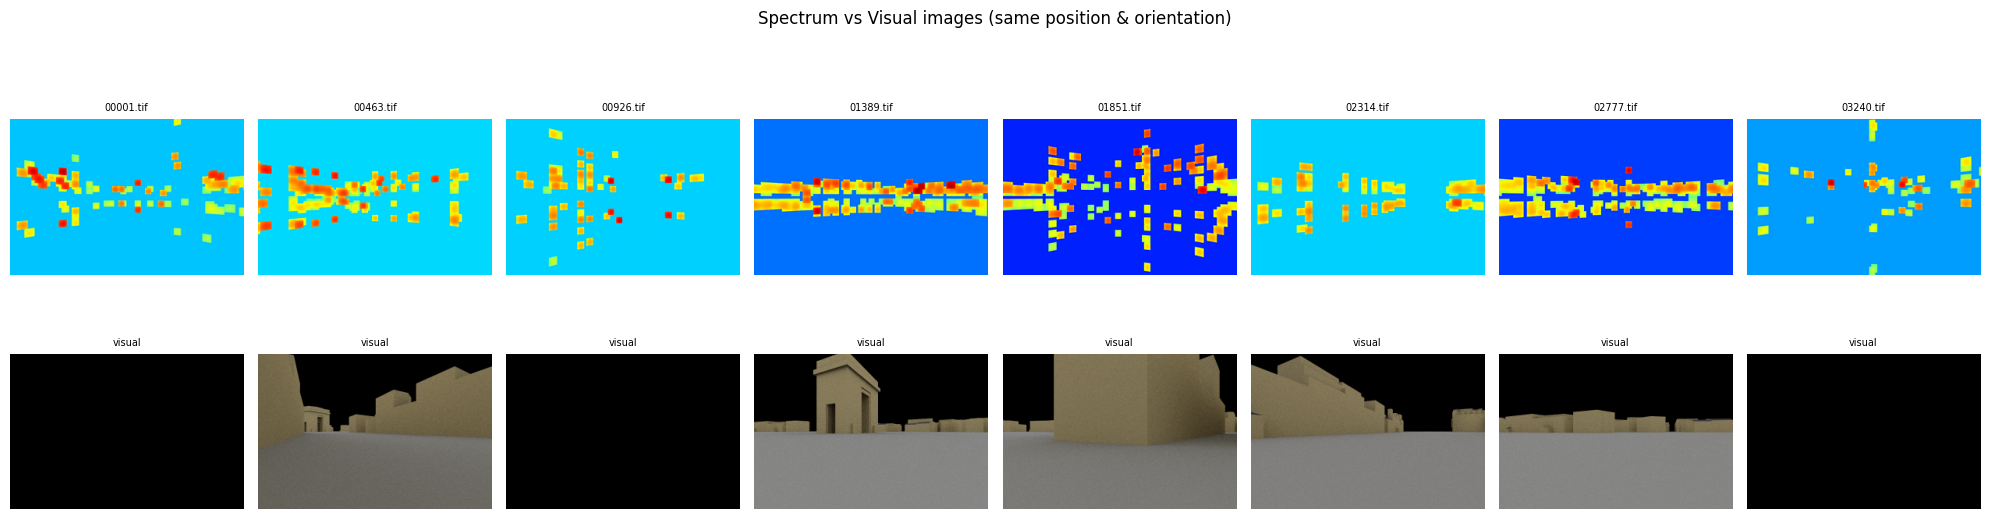

In [14]:
# 随机展示几张生成的频谱图及其对应的视觉图
images_dir = os.path.join(OUTPUT_DIR, 'images')
visual_dir = os.path.join(OUTPUT_DIR, 'visual_images')
all_images = sorted(os.listdir(images_dir))

n_show = min(8, len(all_images))
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.5, 6))

show_indices = np.linspace(0, len(all_images) - 1, n_show, dtype=int)
for col, idx in enumerate(show_indices):
    fname = all_images[idx]
    # 上行: 频谱图
    spec_img = imageio.imread(os.path.join(images_dir, fname))
    axes[0, col].imshow(spec_img)
    axes[0, col].set_title(fname, fontsize=7)
    axes[0, col].axis('off')

    # 下行: 视觉图 (在 train 或 test 子文件下)
    visual_path_train = os.path.join(visual_dir, 'train', fname)
    visual_path_test = os.path.join(visual_dir, 'test', fname)

    if os.path.exists(visual_path_train):
        vis_img = imageio.imread(visual_path_train)
        axes[1, col].imshow(vis_img)
    elif os.path.exists(visual_path_test):
        vis_img = imageio.imread(visual_path_test)
        axes[1, col].imshow(vis_img)

    axes[1, col].set_title('visual', fontsize=7)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Spectrum', fontsize=10)
axes[1, 0].set_ylabel('Visual', fontsize=10)
plt.suptitle('Spectrum vs Visual images (same position & orientation)', fontsize=12)
plt.tight_layout()
plt.show()